In [8]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import torcwa
from tqdm.notebook import tqdm
from pvlib import spectrum
from refractiveindex import RefractiveIndexMaterial
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from Utils.utils import get_absorptance

%load_ext line_profiler

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')



def get_sine_eps(x,params,grating_period,eps):
    """Generate sine grating permittivity profile.

    Args:
        x (torch.tensor): 1D tensor of x positions.
        params (torch.Tensor): list of amplitude and phase shift. shape (n,2), where n is n*2*np.pi/grating_period'th frequency.
        eps (float): Permittivity of high-index material.

    Returns:
        torch.tensor: 1D tensor of permittivity profile.
    """
    A = torch.sum(params[:,0]) + 1e-9
    cosines = torch.cos(2.*np.pi*torch.arange(1, params.shape[0]+1, 
                                              dtype=geo_dtype,device=device).unsqueeze(1)*(x.unsqueeze(0)/grating_period)
                                               - params[:,1].unsqueeze(1))
    cosines = cosines * params[:,0].unsqueeze(1)
    eps = 1 + (eps-1)*(0.5*(A+torch.sum(cosines, dim=0))/A)
    return eps.unsqueeze(1)   # make shape (nx,1) so add_layer accepts it

def get_staircase_sine_eps(x,params,grating_period,num_layers,eps_high,eps_low=1.):
    """"Generate sine grating in stepwise approximation.

    Args:
        x (torch.tensor): 1D tensor of x positions.
        params (torch.Tensor): list of amplitude and phase shift. shape (n,2), where n is n*2*np.pi/grating_period'th frequency.
        num_layers (int): number of layers for stepwise approximation.
        eps_high (float): Permittivity of high-index material.
        eps_low (float, optional): Permittivity of low-index material. Defaults to air, so 1.

    Returns:
        torch.tensor: 2D tensor of permittivity profile with shape (nx,num_layers).
    """
    A = torch.sum(params[:,0]) + 1e-9
    cosines = torch.cos(2.*np.pi*torch.arange(1, params.shape[0]+1, dtype=geo_dtype,device=device).unsqueeze(1)*(x.unsqueeze(0)/grating_period)
                                               - params[:,1].unsqueeze(1))
    cosines = cosines * params[:,0].unsqueeze(1)
    eps_profile = 0.5*(A+torch.sum(cosines, dim=0))
    eps = torch.ones(x.shape[0], num_layers, dtype=geo_dtype, device=device) * eps_low
    for i in range(num_layers):
        eps[:,i] = torch.where(eps_profile > (i+1)*A/num_layers, eps_high, eps_low)

    return eps #Shape is (nx,num_layers) for add_layer


# Simulation environment
# light
inc_ang = 30.*(np.pi/180)    # radian
azi_ang = 30.*(np.pi/180)    # radian
spectra = spectrum.get_reference_spectra()
am15g = spectra['global']
wavelengths = torch.linspace(300,1100,100,dtype=int) # nm
sun_weights = torch.tensor(am15g[wavelengths.cpu().numpy()].to_numpy())

# material
si = RefractiveIndexMaterial(shelf='main', book='Si', page='Green-2008')
si_eps = torch.tensor(si.get_refractive_index(wavelengths.cpu().numpy()) +
                      1j * si.get_extinction_coefficient(wavelengths.cpu().numpy()))**2
#artificial permitivity for perfect conductor
pec_eps = torch.tensor(-1e6 + 0j, dtype=torch.complex64, device=device)

# geometry
h = 1000 #nm
grating_period = 1000 # nm
L = [grating_period, 1.]  # nm
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 100
torcwa.rcwa_geo.ny = 1
torcwa.rcwa_geo.grid()
z = torch.linspace(-h,1.5*h,501,device=device)

x_axis = torcwa.rcwa_geo.x.cpu()
y_axis = torcwa.rcwa_geo.y.cpu()
z_axis = z.cpu()

x = torch.clone(torcwa.rcwa_geo.x)
y  = torch.clone(torcwa.rcwa_geo.y)
z = torch.clone(z)

n_wavelength = 30
print(wavelengths[n_wavelength])

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
tensor(542)


In [9]:
#Sanity check of staircase approximation
num_layers = 100
params = torch.tensor([[20,0],[20,np.pi],[20,0]], dtype=geo_dtype, device=device)
eps = get_staircase_sine_eps(x, params, grating_period, num_layers, si_eps[0], eps_low=1.)

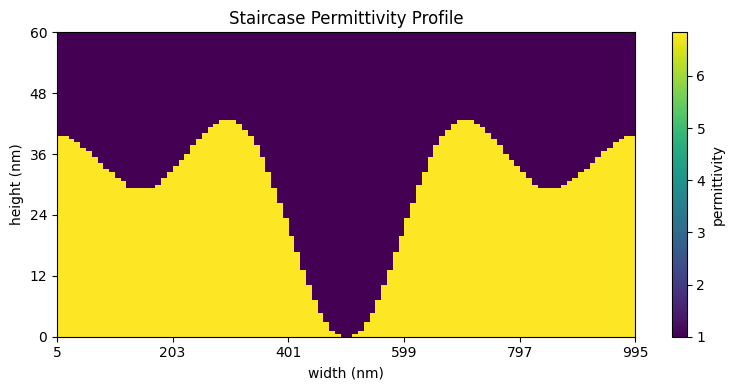

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
x_min_nm = x_axis.min().item()
x_max_nm = x_axis.max().item()
y_min_nm = 0.0
y_max_nm = float(sum(params[:,0]))

im = ax.imshow(
    eps.cpu().T,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    interpolation='none',
    extent=[x_min_nm, x_max_nm, y_min_nm, y_max_nm],
)

ax.set_xticks(np.linspace(x_min_nm, x_max_nm, 6))
ax.set_yticks(np.linspace(y_min_nm, y_max_nm, 6))
ax.set_xlabel('width (nm)')
ax.set_ylabel('height (nm)')
ax.set_title('Staircase Permittivity Profile')
fig.colorbar(im, ax=ax, label='permittivity')
plt.tight_layout()
plt.show()

In [11]:
# Generate and perform simulation
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_staircase_sine_eps(x, params, grating_period, num_layers, si_eps[n_wavelength], eps_low=1.)
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
for i in range(sine_eps.shape[1]):
    sim.add_layer(thickness=A/sine_eps.shape[1],eps=sine_eps[:,-1-i,None])
sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
#add PEC layer under bulk silicon
sim.add_layer(thickness=h/5,eps=pec_eps)
sim.solve_global_smatrix()
# Set source
polarization = [1., 0.] # x-polarized
sim.source_planewave(amplitude=polarization, direction='forward', notation='xy')

# View XZ-plane fields
x_plot = torch.linspace(0, L[0], 500, device=device)
z_plot = torch.linspace(-h, 1.5*h, 1000, device=device)
[Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_plot, z_plot, torch.tensor(0., device=device, dtype=geo_dtype))
Enorm = torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2)
Hnorm = torch.sqrt(torch.abs(Hx)**2 + torch.abs(Hy)**2 + torch.abs(Hz)**2)
Sx = 0.5 * torch.real(Ey * torch.conj(Hz) - Ez * torch.conj(Hy))
Sy = 0.5 * torch.real(Ez * torch.conj(Hx) - Ex * torch.conj(Hz))
Sz = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))
Snorm = torch.sqrt(Sx**2 + Sy**2 + Sz**2)
x_plot = x_plot.cpu()
z_plot = z_plot.cpu()

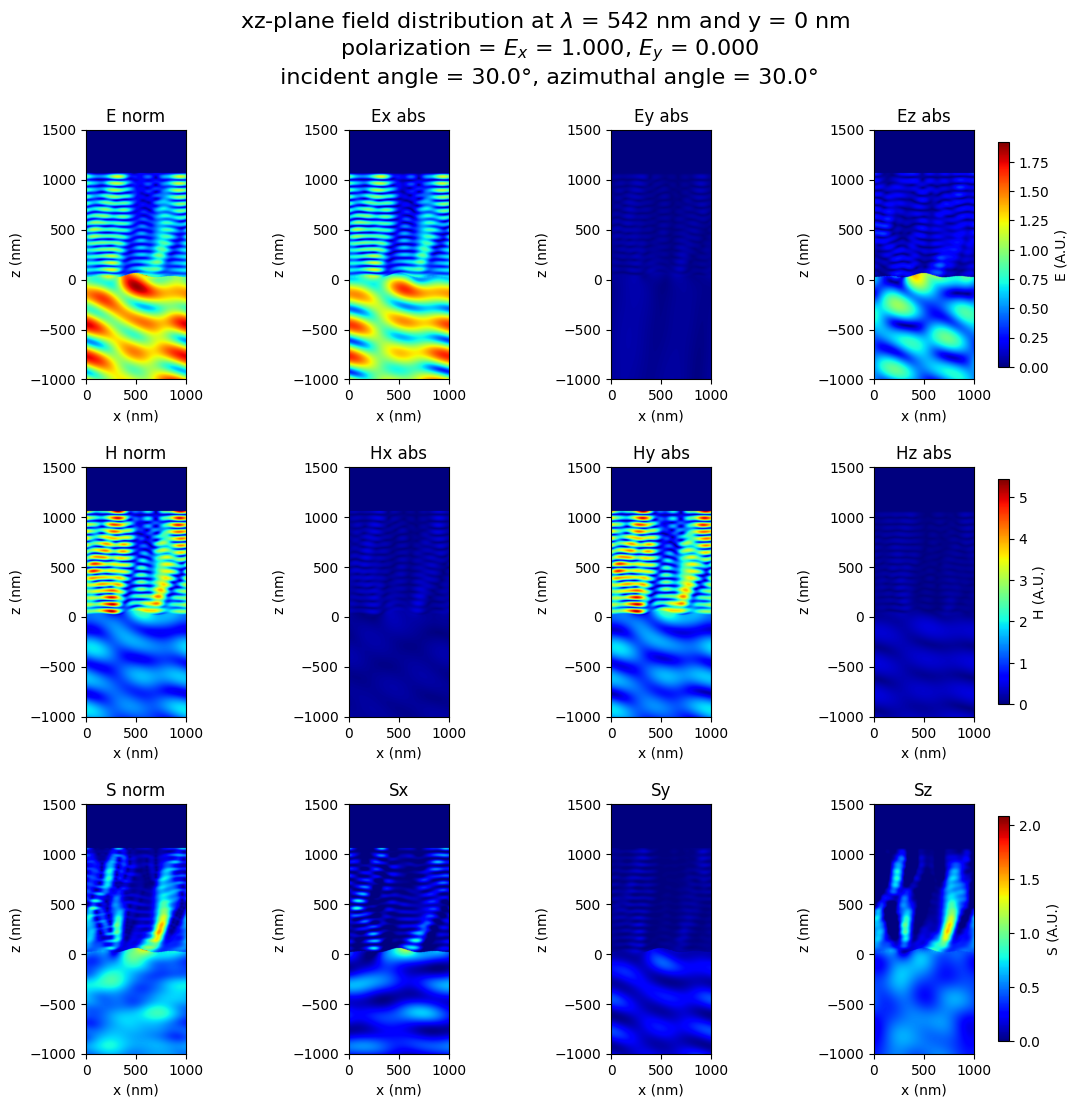

In [12]:
fig, axes = plt.subplots(figsize=(15,12),nrows=3,ncols=4)

# compute per-row vmin/vmax so each row shares a common color scale
row0_imgs = [Enorm, torch.abs(Ex), torch.abs(Ey), torch.abs(Ez)]
row1_imgs = [Hnorm, torch.abs(Hx), torch.abs(Hy), torch.abs(Hz)]
row2_imgs = [Snorm, Sx.abs(), Sy.abs(), Sz.abs()]

row0_vmin = min([x.min().item() for x in row0_imgs])
row0_vmax = max([x.max().item() for x in row0_imgs])
row1_vmin = min([x.min().item() for x in row1_imgs])
row1_vmax = max([x.max().item() for x in row1_imgs])
row2_vmin = min([x.min().item() for x in row2_imgs])
row2_vmax = max([x.max().item() for x in row2_imgs])

im0 = axes[0,0].imshow(torch.transpose(Enorm,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,0].set(title='E norm', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im1 = axes[0,1].imshow(torch.transpose(torch.abs(Ex),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,1].set(title='Ex abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im2 = axes[0,2].imshow(torch.transpose(torch.abs(Ey),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,2].set(title='Ey abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im3 = axes[0,3].imshow(torch.transpose(torch.abs(Ez),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,3].set(title='Ez abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im4 = axes[1,0].imshow(torch.transpose(Hnorm,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,0].set(title='H norm', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im5 = axes[1,1].imshow(torch.transpose(torch.abs(Hx),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,1].set(title='Hx abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im6 = axes[1,2].imshow(torch.transpose(torch.abs(Hy),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,2].set(title='Hy abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im7 = axes[1,3].imshow(torch.transpose(torch.abs(Hz),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,3].set(title='Hz abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im8 = axes[2,0].imshow(torch.transpose(Snorm,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row2_vmin, vmax=row2_vmax)
axes[2,0].set(title='S norm', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im9 = axes[2,1].imshow(torch.transpose(Sx,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row2_vmin, vmax=row2_vmax)
axes[2,1].set(title='Sx', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im10 = axes[2,2].imshow(torch.transpose(Sy,-2,-1).cpu(), cmap='jet', origin='lower',
                        extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                        vmin=row2_vmin, vmax=row2_vmax)
axes[2,2].set(title='Sy', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im11 = axes[2,3].imshow(torch.transpose(Sz,-2,-1).cpu(), cmap='jet', origin='lower',
                        extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                        vmin=row2_vmin, vmax=row2_vmax)
axes[2,3].set(title='Sz', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

# adjust layout to leave room on the right for three colorbars
fig.subplots_adjust(right=0.92, hspace=0.35, wspace=0.3)

# one colorbar per row (uses the representative mappable but all images share vmin/vmax)
cbar0 = fig.colorbar(im0, ax=axes[0, :], location='right', shrink=0.9, pad=0.02)
cbar0.set_label('E (A.U.)')
cbar1 = fig.colorbar(im4, ax=axes[1, :], location='right', shrink=0.9, pad=0.02)
cbar1.set_label('H (A.U.)')
cbar2 = fig.colorbar(im8, ax=axes[2, :], location='right', shrink=0.9, pad=0.02)
cbar2.set_label('S (A.U.)')

fig.suptitle(f'xz-plane field distribution at $\\lambda$ = {wavelength} nm and y = 0 nm \n polarization = $E_x$ = {polarization[0]:.3f}, $E_y$ = {polarization[1]:.3f} \n incident angle = {inc_ang*180/np.pi:.1f}°, azimuthal angle = {azi_ang*180/np.pi:.1f}°', fontsize=16)
plt.show()

In [13]:
# Generate and perform simulation
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_sine_eps(x,params,grating_period,si_eps[n_wavelength])
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
for i in range(sine_eps.shape[1]):
    sim.add_layer(thickness=A/sine_eps.shape[1],eps=sine_eps[:,-1-i,None])
sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
#add PEC layer under bulk silicon
sim.add_layer(thickness=h/5,eps=pec_eps)
sim.solve_global_smatrix()
# Set source
polarization = [1., 0.] # x-polarized
sim.source_planewave(amplitude=polarization, direction='forward', notation='xy')

# View XZ-plane fields
x_plot = torch.linspace(0, L[0], 500, device=device)
z_plot = torch.linspace(-h, 1.5*h, 1000, device=device)
[Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_plot, z_plot, torch.tensor(0., device=device, dtype=geo_dtype))
Enorm = torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2)
Hnorm = torch.sqrt(torch.abs(Hx)**2 + torch.abs(Hy)**2 + torch.abs(Hz)**2)
Sx = 0.5 * torch.real(Ey * torch.conj(Hz) - Ez * torch.conj(Hy))
Sy = 0.5 * torch.real(Ez * torch.conj(Hx) - Ex * torch.conj(Hz))
Sz = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))
Snorm = torch.sqrt(Sx**2 + Sy**2 + Sz**2)
x_plot = x_plot.cpu()
z_plot = z_plot.cpu()


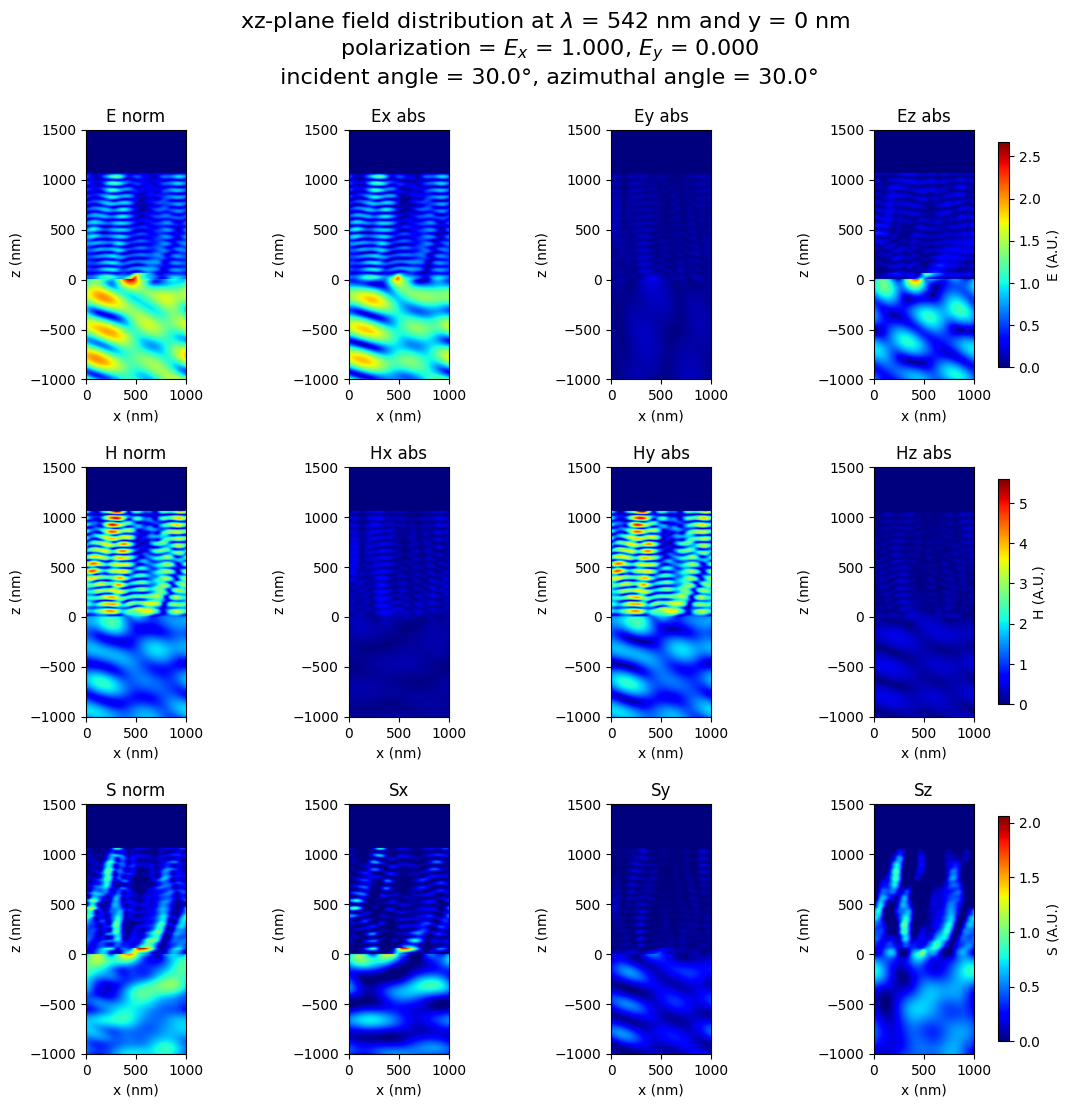

In [14]:
fig, axes = plt.subplots(figsize=(15,12),nrows=3,ncols=4)

# compute per-row vmin/vmax so each row shares a common color scale
row0_imgs = [Enorm, torch.abs(Ex), torch.abs(Ey), torch.abs(Ez)]
row1_imgs = [Hnorm, torch.abs(Hx), torch.abs(Hy), torch.abs(Hz)]
row2_imgs = [Snorm, Sx.abs(), Sy.abs(), Sz.abs()]

row0_vmin = min([x.min().item() for x in row0_imgs])
row0_vmax = max([x.max().item() for x in row0_imgs])
row1_vmin = min([x.min().item() for x in row1_imgs])
row1_vmax = max([x.max().item() for x in row1_imgs])
row2_vmin = min([x.min().item() for x in row2_imgs])
row2_vmax = max([x.max().item() for x in row2_imgs])

im0 = axes[0,0].imshow(torch.transpose(Enorm,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,0].set(title='E norm', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im1 = axes[0,1].imshow(torch.transpose(torch.abs(Ex),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,1].set(title='Ex abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im2 = axes[0,2].imshow(torch.transpose(torch.abs(Ey),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,2].set(title='Ey abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im3 = axes[0,3].imshow(torch.transpose(torch.abs(Ez),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,3].set(title='Ez abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im4 = axes[1,0].imshow(torch.transpose(Hnorm,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,0].set(title='H norm', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im5 = axes[1,1].imshow(torch.transpose(torch.abs(Hx),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,1].set(title='Hx abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im6 = axes[1,2].imshow(torch.transpose(torch.abs(Hy),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,2].set(title='Hy abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im7 = axes[1,3].imshow(torch.transpose(torch.abs(Hz),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,3].set(title='Hz abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im8 = axes[2,0].imshow(torch.transpose(Snorm,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row2_vmin, vmax=row2_vmax)
axes[2,0].set(title='S norm', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im9 = axes[2,1].imshow(torch.transpose(Sx,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row2_vmin, vmax=row2_vmax)
axes[2,1].set(title='Sx', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im10 = axes[2,2].imshow(torch.transpose(Sy,-2,-1).cpu(), cmap='jet', origin='lower',
                        extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                        vmin=row2_vmin, vmax=row2_vmax)
axes[2,2].set(title='Sy', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im11 = axes[2,3].imshow(torch.transpose(Sz,-2,-1).cpu(), cmap='jet', origin='lower',
                        extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                        vmin=row2_vmin, vmax=row2_vmax)
axes[2,3].set(title='Sz', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

# adjust layout to leave room on the right for three colorbars
fig.subplots_adjust(right=0.92, hspace=0.35, wspace=0.3)

# one colorbar per row (uses the representative mappable but all images share vmin/vmax)
cbar0 = fig.colorbar(im0, ax=axes[0, :], location='right', shrink=0.9, pad=0.02)
cbar0.set_label('E (A.U.)')
cbar1 = fig.colorbar(im4, ax=axes[1, :], location='right', shrink=0.9, pad=0.02)
cbar1.set_label('H (A.U.)')
cbar2 = fig.colorbar(im8, ax=axes[2, :], location='right', shrink=0.9, pad=0.02)
cbar2.set_label('S (A.U.)')

fig.suptitle(f'xz-plane field distribution at $\\lambda$ = {wavelength} nm and y = 0 nm \n polarization = $E_x$ = {polarization[0]:.3f}, $E_y$ = {polarization[1]:.3f} \n incident angle = {inc_ang*180/np.pi:.1f}°, azimuthal angle = {azi_ang*180/np.pi:.1f}°', fontsize=16)
plt.show()